# Step 16 -> EDA & Visualizations 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
model_df = pd.read_csv("data/processed/modeling_data_features.csv")
model_df["date"] = pd.to_datetime(model_df["date"])

## EDA copy without early-history null rows

In [4]:
eda_df = model_df.dropna(subset=["rolling_mean_7", "rolling_mean_14", "lag_7", "lag_14"]).copy()
eda_df.shape

(2975940, 37)

## Total sales trend over time 

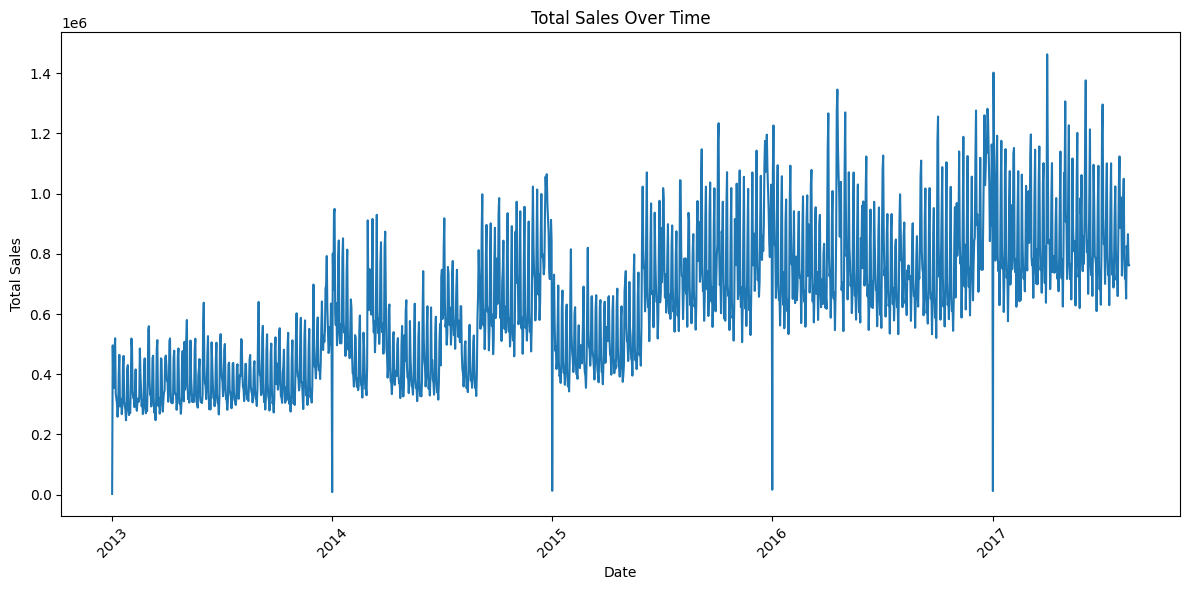

In [5]:
daily_sales = model_df.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## top 10 product families by total sales

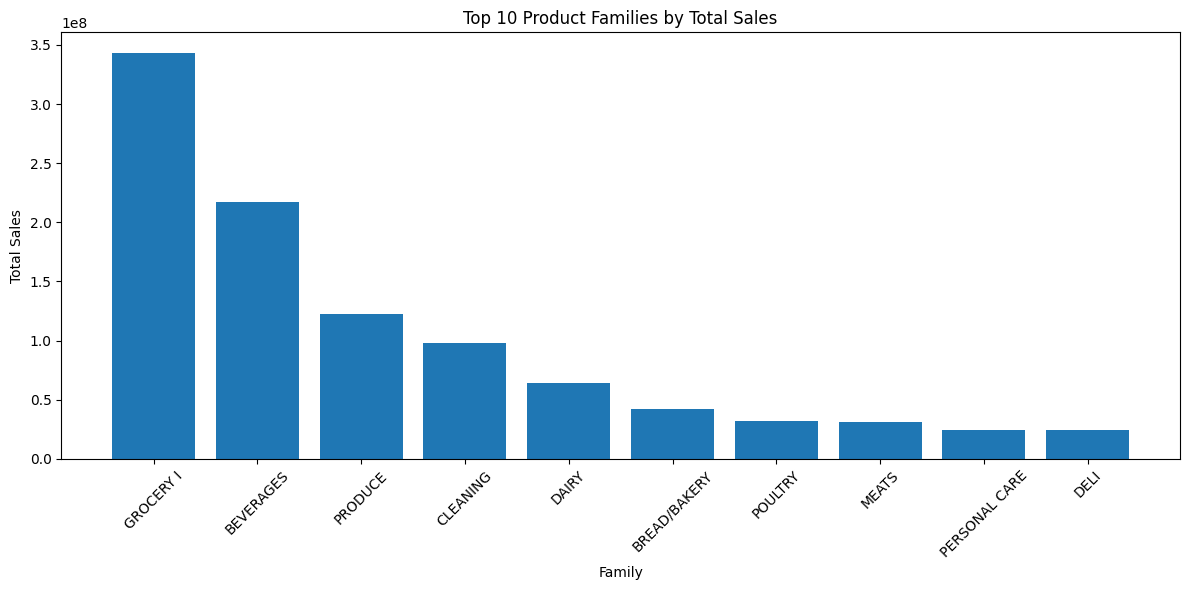

In [6]:
top_families = (
    model_df.groupby("family", as_index=False)["sales"]
    .sum()
    .sort_values("sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.bar(top_families["family"], top_families["sales"])
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## promotion vs no promotion sales

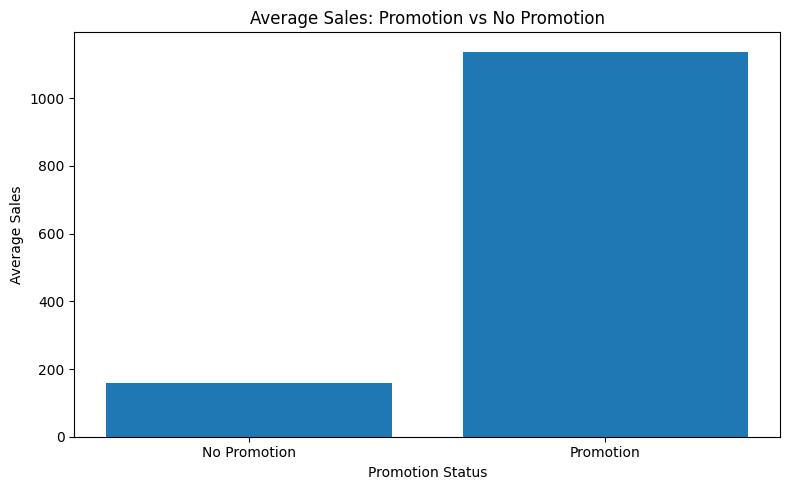

In [7]:
promo_sales = (
    model_df.groupby("has_promotion", as_index=False)["sales"]
    .mean()
)

promo_sales["promo_label"] = promo_sales["has_promotion"].map({0: "No Promotion", 1: "Promotion"})

plt.figure(figsize=(8, 5))
plt.bar(promo_sales["promo_label"], promo_sales["sales"])
plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## average sales by weekday

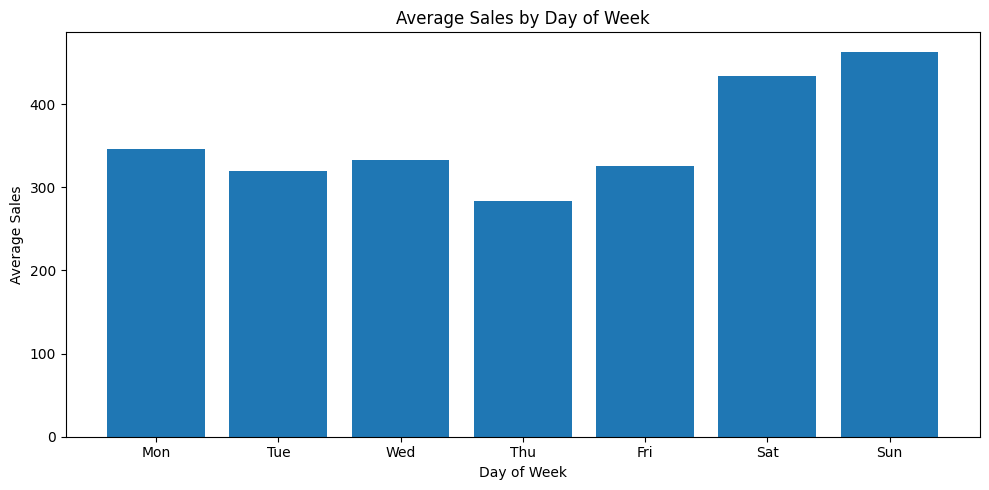

In [8]:
weekday_sales = (
    model_df.groupby("day_of_week", as_index=False)["sales"]
    .mean()
    .sort_values("day_of_week")
)

weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}
weekday_sales["weekday_name"] = weekday_sales["day_of_week"].map(weekday_map)

plt.figure(figsize=(10, 5))
plt.bar(weekday_sales["weekday_name"], weekday_sales["sales"])
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## Monthly seasonality

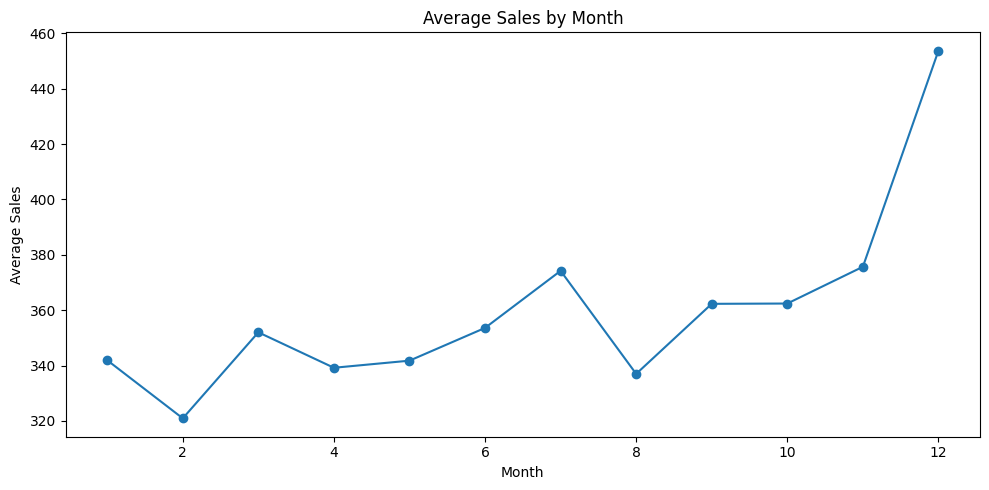

In [9]:
monthly_sales = (
    model_df.groupby("month", as_index=False)["sales"]
    .mean()
    .sort_values("month")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["month"], monthly_sales["sales"], marker="o")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## Sales distribution

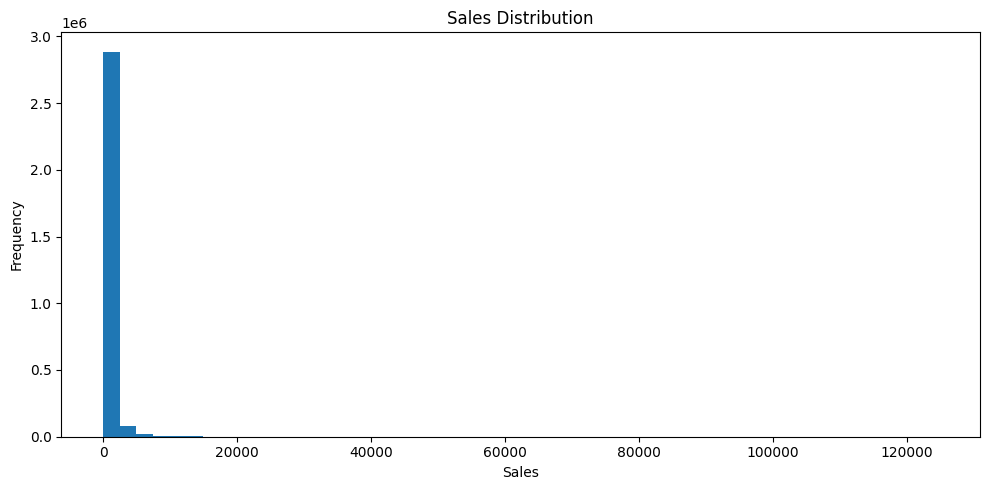

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(model_df["sales"], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Log-transformed sales distribution

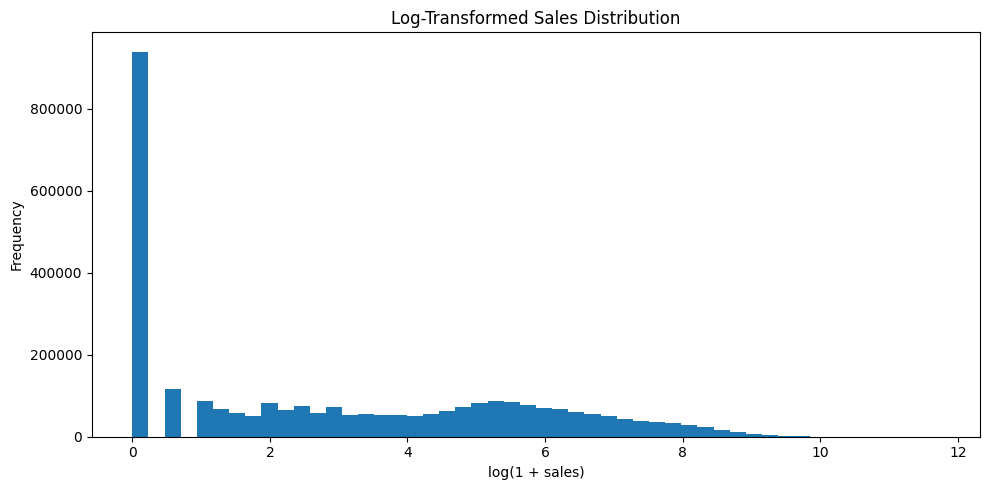

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(model_df["sales"]), bins=50)
plt.title("Log-Transformed Sales Distribution")
plt.xlabel("log(1 + sales)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Transactions vs Sales

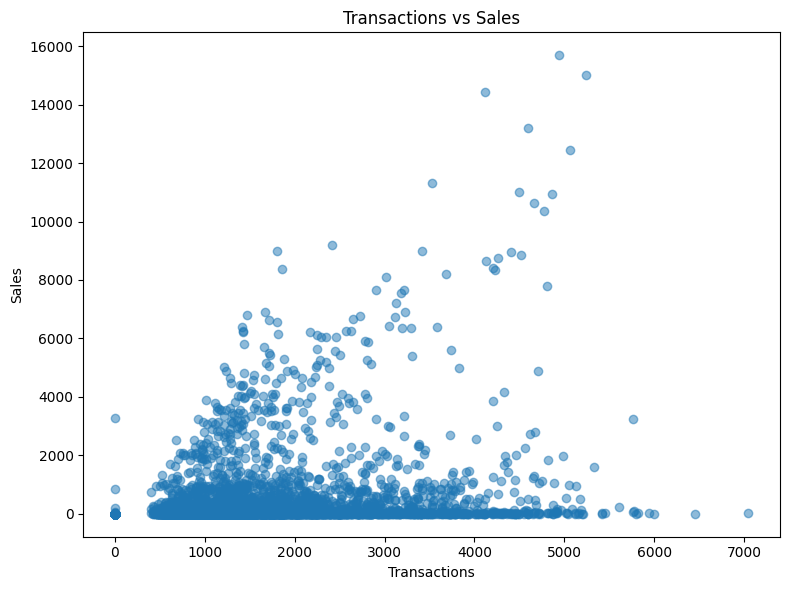

In [12]:
sample_df = model_df.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df["transactions"], sample_df["sales"], alpha=0.5)
plt.title("Transactions vs Sales")
plt.xlabel("Transactions")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## Stockout Risk Distribution

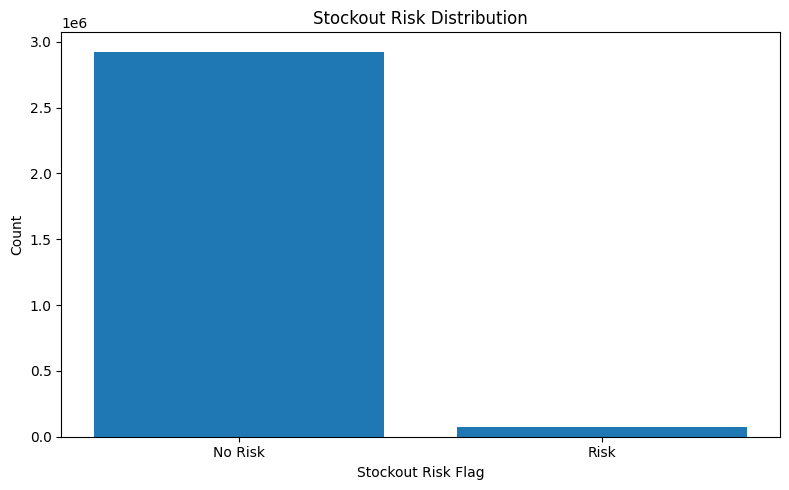

In [13]:
risk_counts = model_df["stockout_risk_flag"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(["No Risk", "Risk"], risk_counts.values)
plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk Flag")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## days until stockout distribution

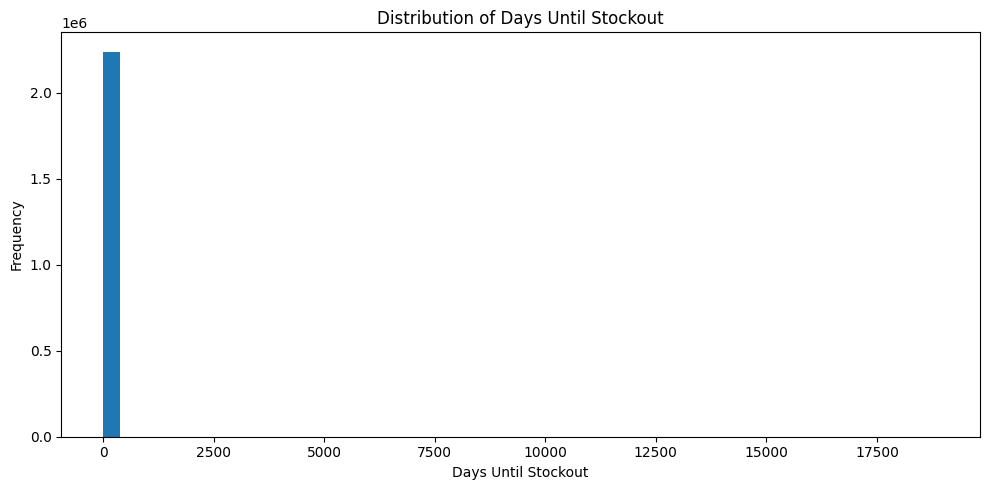

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(model_df["days_until_stockout"].dropna(), bins=50)
plt.title("Distribution of Days Until Stockout")
plt.xlabel("Days Until Stockout")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Top risky Families

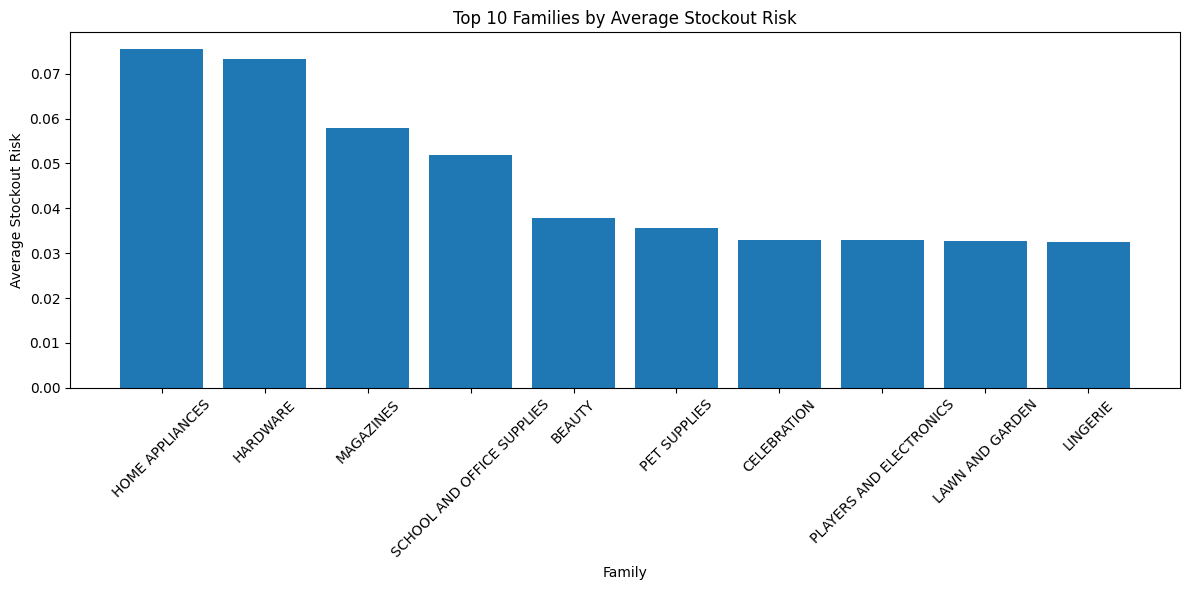

In [15]:
risk_by_family = (
    model_df.groupby("family", as_index=False)["stockout_risk_flag"]
    .mean()
    .sort_values("stockout_risk_flag", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.bar(risk_by_family["family"], risk_by_family["stockout_risk_flag"])
plt.title("Top 10 Families by Average Stockout Risk")
plt.xlabel("Family")
plt.ylabel("Average Stockout Risk")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## correlation heatmap for numeric features

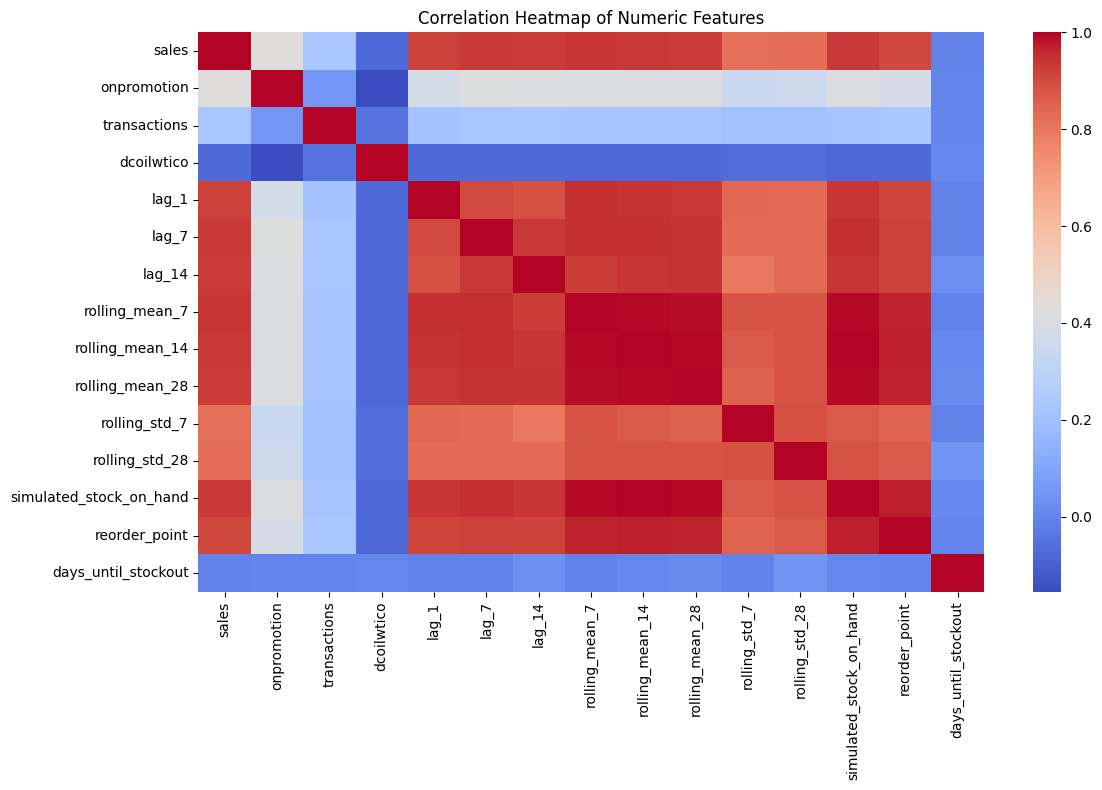

In [17]:
numeric_cols = [
    "sales", "onpromotion", "transactions", "dcoilwtico",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_28",
    "simulated_stock_on_hand", "reorder_point", "days_until_stockout"
]

corr_df = model_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## Step 16 — EDA findings

- Sales are highly right-skewed, with many low-sales observations and a smaller number of very large values.
- A small number of product families contribute a large share of overall sales.
- Promotions are associated with higher average sales.
- Sales vary by weekday, showing clear weekly seasonality.
- Monthly patterns suggest broader seasonal behavior.
- Transactions appear positively related to sales and may be useful for forecasting.
- Stockout risk is concentrated more heavily in some product families than others.